In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

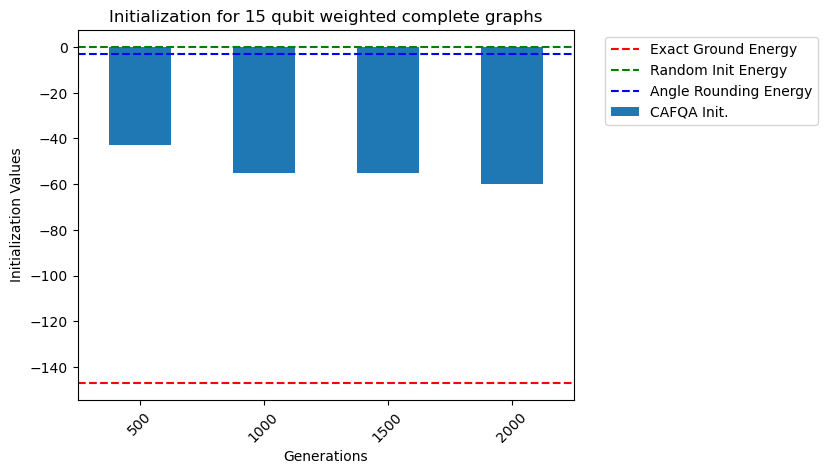

In [2]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Generations': [500,1000,1500,2000],
    'CAFQA Init.': [-43,-55,-55,-60]
})

df.plot(x='Generations', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Generations')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()


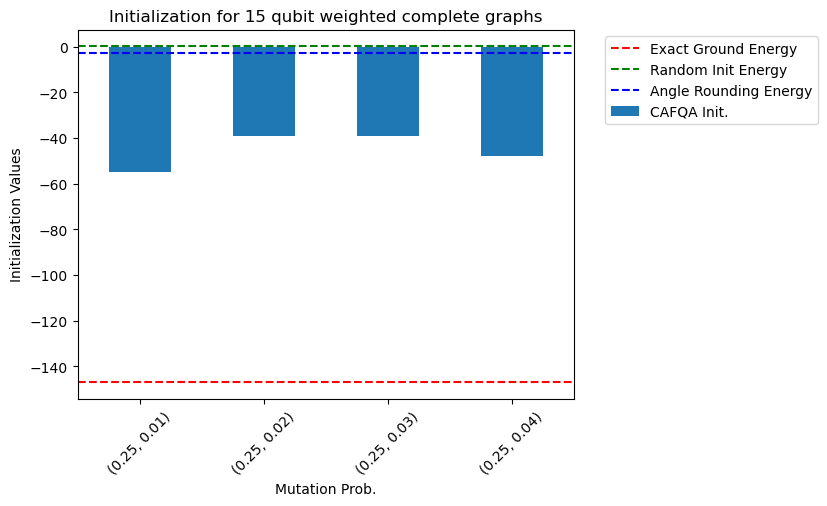

In [3]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Mutation Prob.': [(0.25,0.01),(0.25,0.02),(0.25,0.03),(0.25,0.04)],
    'CAFQA Init.': [-55,-39,-39,-48]
})

df.plot(x='Mutation Prob.', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Mutation Prob.')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()


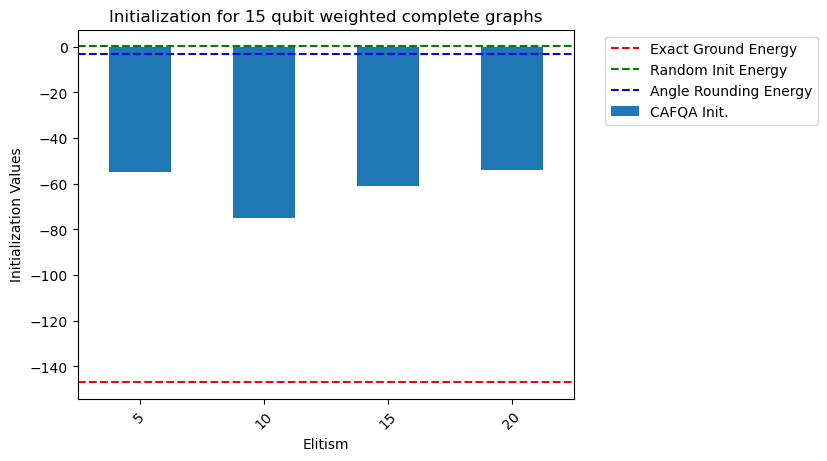

In [4]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Elitism': [5,10,15,20],
    'CAFQA Init.': [-55,-75,-61,-54]
})

df.plot(x='Elitism', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Elitism')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()

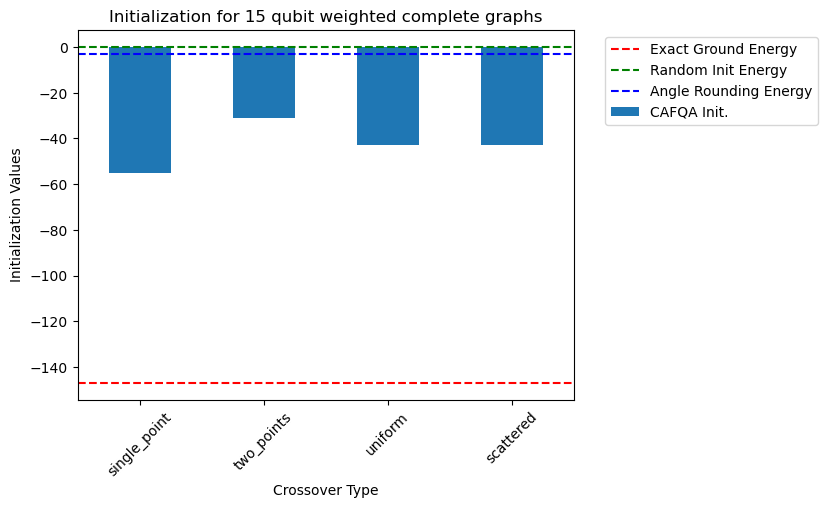

In [5]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Elitism': ["single_point","two_points", "uniform", "scattered"],
    'CAFQA Init.': [-55,-31,-43,-43]
})

df.plot(x='Elitism', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Crossover Type')
plt.ylabel('Initialization Values')
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.xticks(rotation=45)
plt.show()

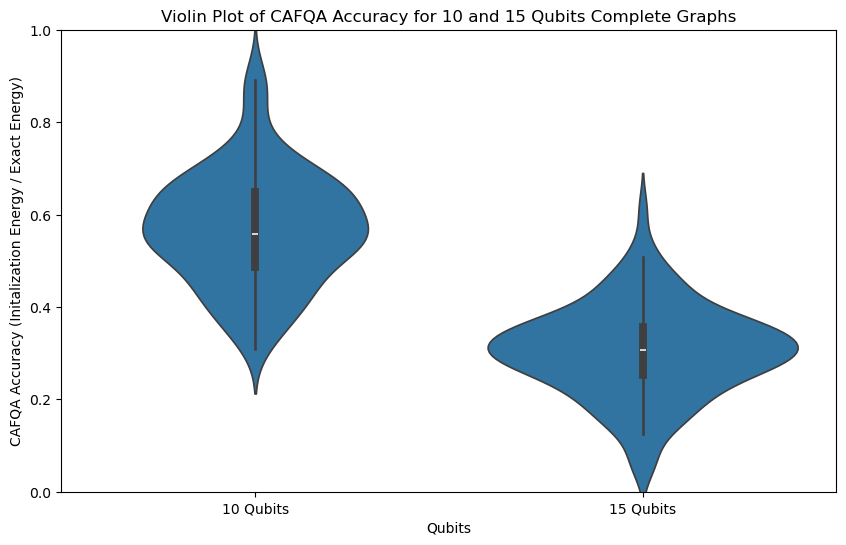

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['CAFQA_Accuracy'] = data['CAFQA_initialization'] / data['Exact_solution']
        data['Random_Accuracy'] = data['Random_initialization'] / data['Exact_solution']
        data['Angle_Rounding_Accuracy'] = data['Angle_rounding'] / data['Exact_solution']
        data_list.append(data)
    return pd.DataFrame(data_list)

# Load data for 10 and 15 qubits
df_10 = load_data(10, '../np_data/10_qbs/energies_{}.npz.npy', 100)
df_15 = load_data(15, '../np_data/15_qbs/energies_{}.npy', 100)

# Combine the dataframes
df_combined = pd.concat([df_10, df_15])

# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits', y='CAFQA_Accuracy', data=df_combined)
plt.title('Violin Plot of CAFQA Accuracy for 10 and 15 Qubits Complete Graphs')
plt.ylabel('CAFQA Accuracy (Initalization Energy / Exact Energy)')
plt.ylim(0, 1)
plt.show()

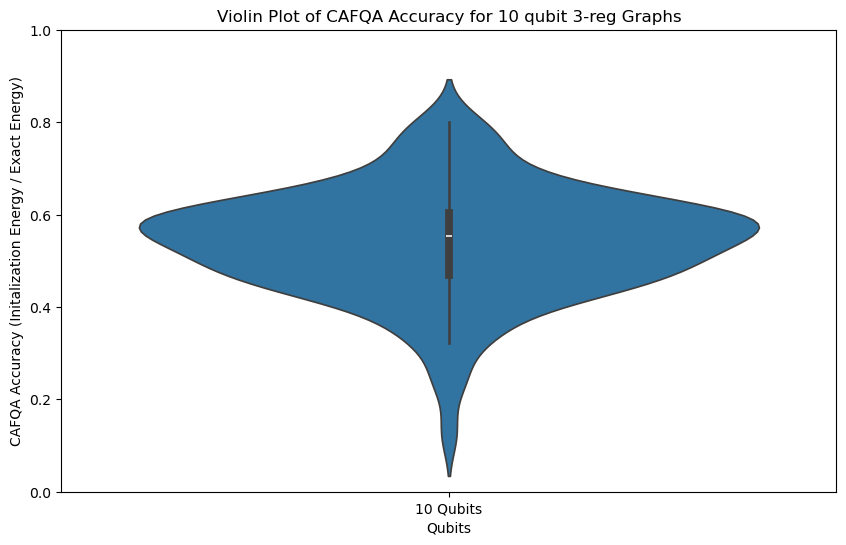

In [7]:


df_10_k_reg = load_data(10, '../np_data/10_qbs/k_reg_energies_{}.npy', 100)

plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits',y='CAFQA_Accuracy',data=df_10_k_reg)
plt.title('Violin Plot of CAFQA Accuracy for 10 qubit 3-reg Graphs')
plt.ylabel('CAFQA Accuracy (Initalization Energy / Exact Energy)')
plt.ylim(0, 1)
plt.show()


In [8]:
df_10['CAFQA_initialization'].mean(),df_15['CAFQA_initialization'].mean()

(np.float64(-43.71), np.float64(-43.01))

In [9]:
def load_sweep_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['Init_CAFQA_Accuracy'] = data['CAFQA_initialization_energy'] / data['Exact_solution_energy']
        data['Init_Random_Accuracy'] = data['Random_initialization_energy'] / data['Exact_solution_energy']
        data['Init_Angle_Rounding_Accuracy'] = data['Angle_rounding_energy'] / data['Exact_solution_energy']

        data['Final_random_Accuracy'] = data['Final_random_energy'] / data['Exact_solution_energy']
        data['Final_Rounded_Accuracy'] = data['Final_Rounded_Angle_energy'] / data['Exact_solution_energy']
        data['Final_cafqa_Accuracy'] = data['Final_cafqa_energy'] / data['Exact_solution_energy']

        data['Init_CAFQA_to_Random_Energy_Ratio'] = data['CAFQA_initialization_energy'] / data['Random_initialization_energy']
        data['Final_CAFQA_to_Random_Energy_Ratio'] = abs(data['Final_cafqa_energy'] / (data['Final_random_energy'] - 1))

        data_list.append(data)
    return pd.DataFrame(data_list)


df_1_layer = load_sweep_data(15, '../np_data/rep_sweep/1_layers/results_{}.npy', 5)
df_2_layer = load_sweep_data(15, '../np_data/rep_sweep/2_layers/results_{}.npy', 5)
df_5_layer = load_sweep_data(15, '../np_data/rep_sweep/5_layers/results_{}.npy', 5)


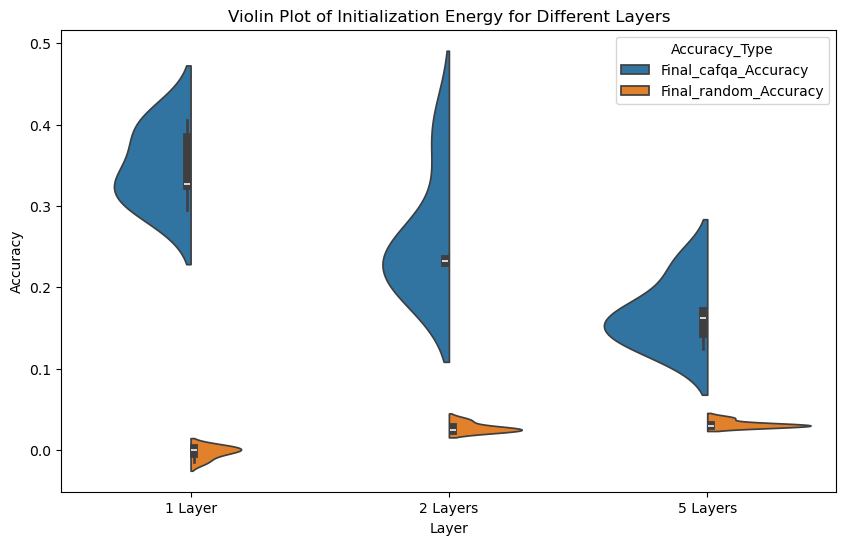

In [10]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='1 Layer'),
    df_2_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='2 Layers'),
    df_5_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='5 Layers')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer', 'Qubits'], value_vars=['Final_cafqa_Accuracy', 'Final_random_Accuracy'], var_name='Accuracy_Type', value_name='Accuracy')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted, split=True)
plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.show()


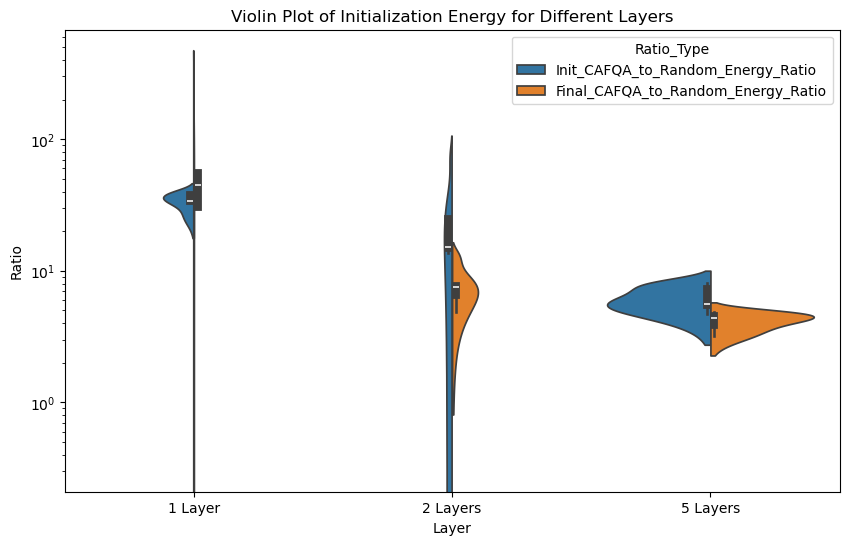

In [11]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio', 'Qubits']].assign(Layer='1 Layer'),
    df_2_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio', 'Qubits']].assign(Layer='2 Layers'),
    df_5_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio', 'Qubits']].assign(Layer='5 Layers')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer', 'Qubits'], 
                               value_vars=['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio'], 
                               var_name='Ratio_Type', value_name='Ratio')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Ratio', hue='Ratio_Type', data=df_melted, split=True)
plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.yscale('log')
plt.show()

In [12]:
df_1_layer = load_sweep_data(10, '../np_data/rep_sweep_2000_gens/1_layers/results_{}.npy', 5)
df_2_layer = load_sweep_data(10, '../np_data/rep_sweep_2000_gens/2_layers/results_{}.npy', 5)
df_5_layer = load_sweep_data(10, '../np_data/rep_sweep_2000_gens/5_layers/results_{}.npy', 5)

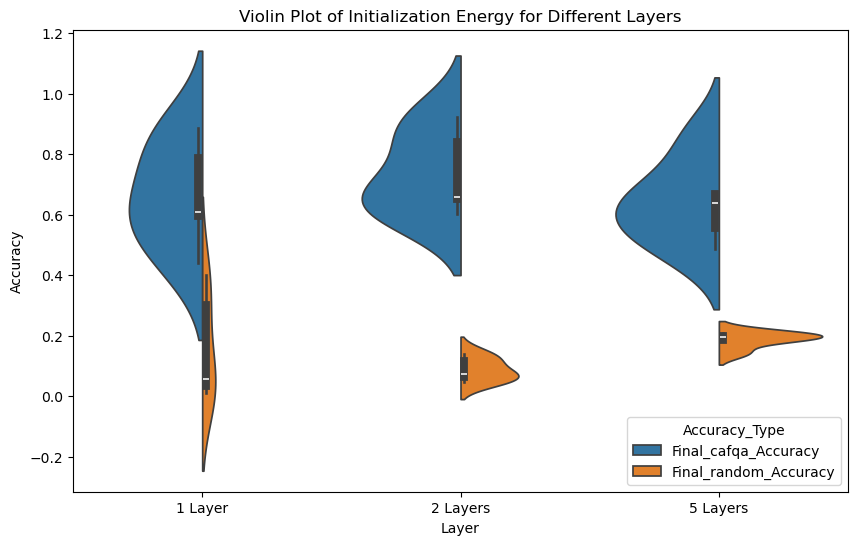

In [13]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='1 Layer'),
    df_2_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='2 Layers'),
    df_5_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='5 Layers')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer', 'Qubits'], value_vars=['Final_cafqa_Accuracy', 'Final_random_Accuracy'], var_name='Accuracy_Type', value_name='Accuracy')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted, split=True)
plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.show()

In [14]:
df_1_layer[['Final_cafqa_Accuracy']].mean(),df_2_layer[['Final_cafqa_Accuracy']].mean(),df_5_layer[['Final_cafqa_Accuracy']].mean(),

(Final_cafqa_Accuracy    0.663036
 dtype: float64,
 Final_cafqa_Accuracy    0.735593
 dtype: float64,
 Final_cafqa_Accuracy    0.641456
 dtype: float64)

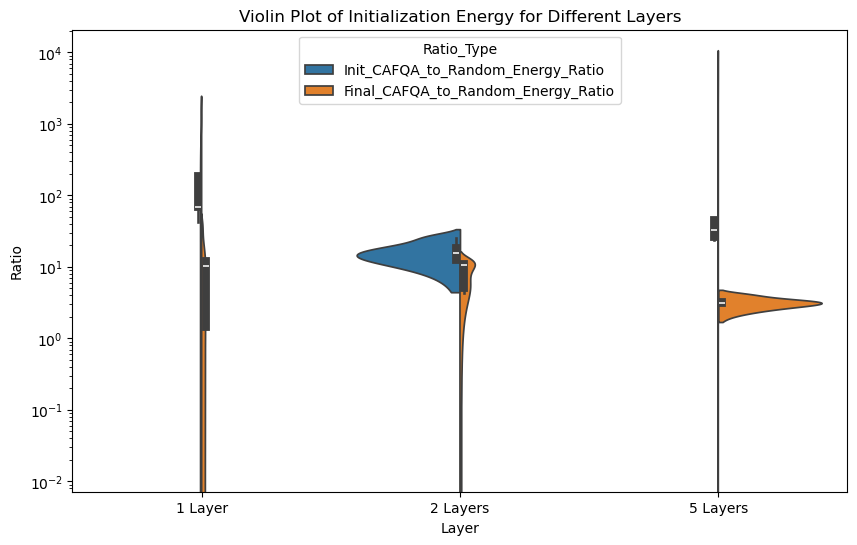

In [15]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().assign(Layer='1 Layer'),
    df_2_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().assign(Layer='2 Layers'),
    df_5_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().assign(Layer='5 Layers')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer'], 
                               value_vars=['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio'], 
                               var_name='Ratio_Type', value_name='Ratio')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Ratio', hue='Ratio_Type', data=df_melted, split=True)
plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.yscale('log')
plt.show()

In [16]:
df_1_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().mean(),df_2_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().mean(),df_5_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().mean()

(Init_CAFQA_to_Random_Energy_Ratio     376.312432
 Final_CAFQA_to_Random_Energy_Ratio     12.118759
 dtype: float64,
 Init_CAFQA_to_Random_Energy_Ratio     16.988466
 Final_CAFQA_to_Random_Energy_Ratio     8.429281
 dtype: float64,
 Init_CAFQA_to_Random_Energy_Ratio     1313.080330
 Final_CAFQA_to_Random_Energy_Ratio       3.190855
 dtype: float64)

# Knapsack Problems

In [17]:
def load_knapsack_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['Init_CAFQA_Accuracy'] = data['CAFQA_energy'] / data['Exact_solution_energy']
        data['Init_Random_Accuracy'] = data['Min_random_energy'] / data['Exact_solution_energy']
        # data['Init_Angle_Rounding_Accuracy'] = data['Angle_rounding_energy'] / data['Exact_solution_energy']

        # data['Final_random_Accuracy'] = data['Final_random_energy'] / data['Exact_solution_energy']
        # data['Final_Rounded_Accuracy'] = data['Final_Rounded_Angle_energy'] / data['Exact_solution_energy']
        # data['Final_cafqa_Accuracy'] = data['Final_cafqa_energy'] / data['Exact_solution_energy']

        # data['Init_CAFQA_to_Random_Energy_Ratio'] = data['CAFQA_initialization_energy'] / data['Random_initialization_energy']
        # data['Final_CAFQA_to_Random_Energy_Ratio'] = abs(data['Final_cafqa_energy'] / (data['Final_random_energy'] - 1))

        data_list.append(data)
    return pd.DataFrame(data_list)



knapsack_df = load_knapsack_data(15, '../np_data/knapsack/16_qubits/results_{}.npy', 10)

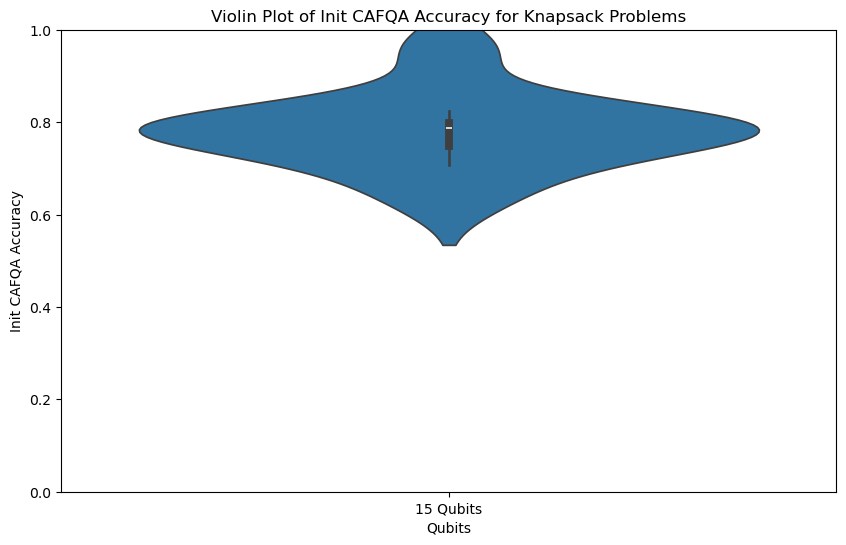

In [18]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits', y='Init_CAFQA_Accuracy', data=knapsack_df)
plt.title('Violin Plot of Init CAFQA Accuracy for Knapsack Problems')
plt.ylabel('Init CAFQA Accuracy')
plt.ylim(0, 1)
plt.show()

In [19]:
max_init_cafqa_accuracy = knapsack_df['Init_CAFQA_Accuracy'].max()
print(max_init_cafqa_accuracy)

0.9567190933271655


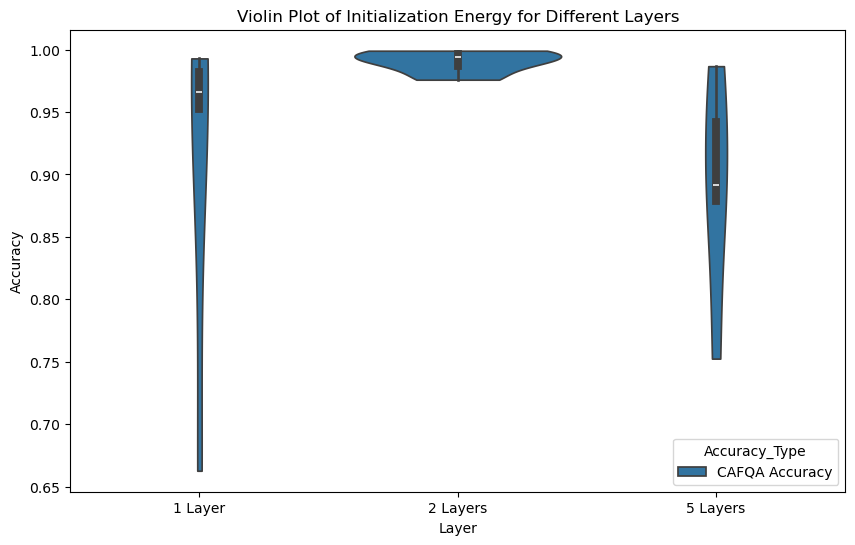

In [21]:
#Parameter sweep for knapsack 

# Manually create dictionaries for each layer
data_1_layer = {
    'Layer': ['1 Layer', '1 Layer', '1 Layer', '1 Layer', '1 Layer'],
    'CAFQA Accuracy': [-25417.5/-26316.5, 
                       -7744.0/-7886.0, 
                       -19624.0/-19764.0, 
                       -10628.0/-11154.5, 
                       -15750.0/-23761.5],
}

data_2_layer = {
    'Layer': ['2 Layers', '2 Layers', '2 Layers', '2 Layers', '2 Layers'],
    'CAFQA Accuracy': [-26292.0/-26316.5, 
                        -7781.0/-7886.0, 
                        -19287.5/-19764.0, 
                        -11112.5/-11154.5, 
                        -23614.5/-23761.5],
}

data_5_layer = {
    'Layer': ['5 Layers', '5 Layers', '5 Layers', '5 Layers', '5 Layers'],
    'CAFQA Accuracy': [-19805.5/-26316.5,
                       -7781.0/-7886.0, 
                       -18624.5/-19764.0,
                         -9944.0/-11154.5, 
                         -20887.0/-23761.5],
}

# Combine the dictionaries into a single DataFrame for plotting
combined_data = {
    'Layer': data_1_layer['Layer'] + data_2_layer['Layer'] + data_5_layer['Layer'],
    'CAFQA Accuracy': data_1_layer['CAFQA Accuracy'] + data_2_layer['CAFQA Accuracy'] + data_5_layer['CAFQA Accuracy'],
    # 'Random Accuracy': data_1_layer['Random Accuracy'] + data_2_layer['Random Accuracy'] + data_5_layer['Random Accuracy']
}

# Convert the combined data into a DataFrame
df_combined = pd.DataFrame(combined_data)

# Plot the violin plot for both CAFQA Accuracy and Random Accuracy
df_melted = df_combined.melt(id_vars=['Layer'], value_vars=['CAFQA Accuracy'], 
                             var_name='Accuracy_Type', value_name='Accuracy')

plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted, split=False,cut=0)
plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.show()